In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv(
    'diabetes_prediction_dataset.csv',
    sep=';'
)

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,800,0,1,never,2519,66,140,0
1,Female,540,0,0,No Info,2732,66,80,0
2,Male,280,0,0,never,2732,57,158,0
3,Female,360,0,0,current,2345,50,155,0
4,Male,760,1,1,current,2014,48,155,0


In [3]:
print(df.shape)

df.info()

print(
    df.isnull().sum()
)

(100000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   gender               100000 non-null  str  
 1   age                  100000 non-null  int64
 2   hypertension         100000 non-null  int64
 3   heart_disease        100000 non-null  int64
 4   smoking_history      100000 non-null  str  
 5   bmi                  100000 non-null  int64
 6   HbA1c_level          100000 non-null  int64
 7   blood_glucose_level  100000 non-null  int64
 8   diabetes             100000 non-null  int64
dtypes: int64(7), str(2)
memory usage: 6.9 MB
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [4]:
df['age']=df['age']/10

df['bmi']=df['bmi']/100

df['HbA1c_level']=(
    df['HbA1c_level']/10
)

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
le_gender=LabelEncoder()

le_smoking=LabelEncoder()

df['gender']=(
    le_gender.fit_transform(
        df['gender']
    )
)

df['smoking_history']=(
    le_smoking.fit_transform(
        df[
            'smoking_history'
        ]
    )
)

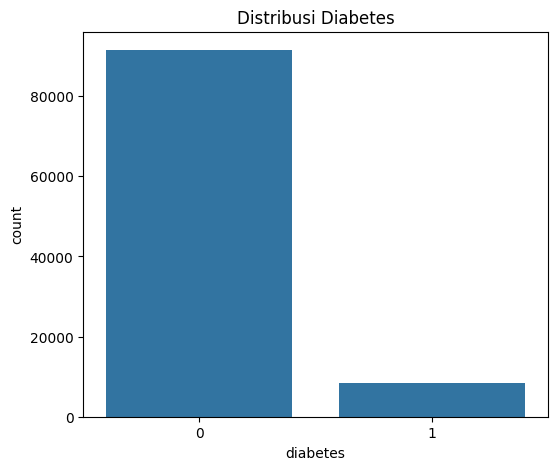

In [6]:
plt.figure(
    figsize=(6,5)
)

sns.countplot(
    x='diabetes',
    data=df
)

plt.title(
    'Distribusi Diabetes'
)

plt.show()

In [7]:
X=df.drop(
    'diabetes',
    axis=1
)

y=df[
    'diabetes'
]

In [8]:
X_train,\
X_test,\
y_train,\
y_test=(
train_test_split(
X,
y,

test_size=0.2,

random_state=42,

stratify=y
))

In [9]:
print(
y_train.value_counts()
)

smote=SMOTE(
random_state=42
)

X_train,\
y_train=(
smote.fit_resample(
X_train,
y_train
))

print(
y_train.value_counts()
)

diabetes
0    73200
1     6800
Name: count, dtype: int64
diabetes
1    73200
0    73200
Name: count, dtype: int64


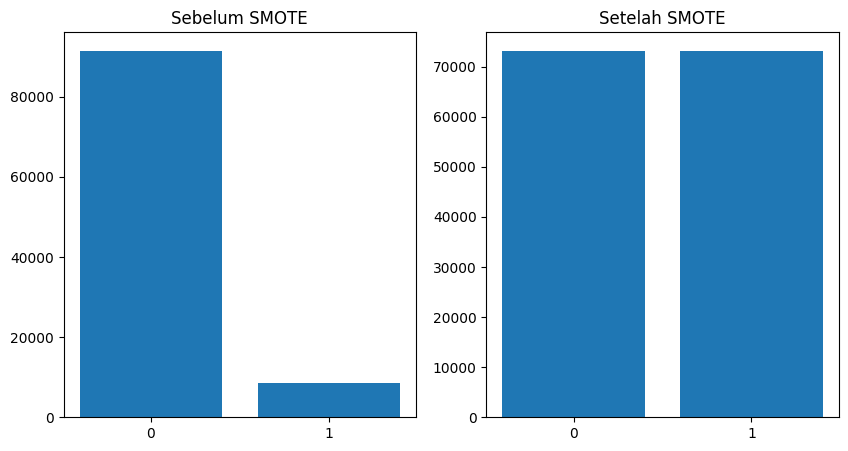

In [10]:
fig,ax=plt.subplots(
1,
2,

figsize=(10,5)
)

before=y.value_counts()

after=y_train.value_counts()

ax[0].bar(
['0','1'],
before
)

ax[0].set_title(
'Sebelum SMOTE'
)

ax[1].bar(
['0','1'],
after
)

ax[1].set_title(
'Setelah SMOTE'
)

plt.show()

In [11]:
rf=(
RandomForestClassifier(

n_estimators=300,

max_depth=10,

random_state=42,

n_jobs=-1
))

rf.fit(
X_train,
y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
y_pred=(
rf.predict(
X_test
))

y_prob=(
rf.predict_proba(
X_test
)[:,1]
)

In [13]:
acc=(
accuracy_score(
y_test,
y_pred
))

print(
f'Accuracy : {acc*100:.2f}%'
)

Accuracy : 90.70%


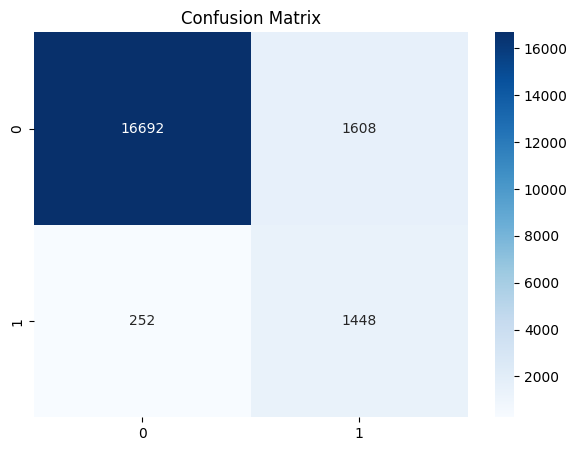

In [14]:
cm=(
confusion_matrix(
y_test,
y_pred
))

plt.figure(
figsize=(7,5)
)

sns.heatmap(
cm,

annot=True,

fmt='d',

cmap='Blues'
)

plt.title(
'Confusion Matrix'
)

plt.show()

In [15]:
print(
classification_report(
y_test,
y_pred
))

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     18300
           1       0.47      0.85      0.61      1700

    accuracy                           0.91     20000
   macro avg       0.73      0.88      0.78     20000
weighted avg       0.94      0.91      0.92     20000



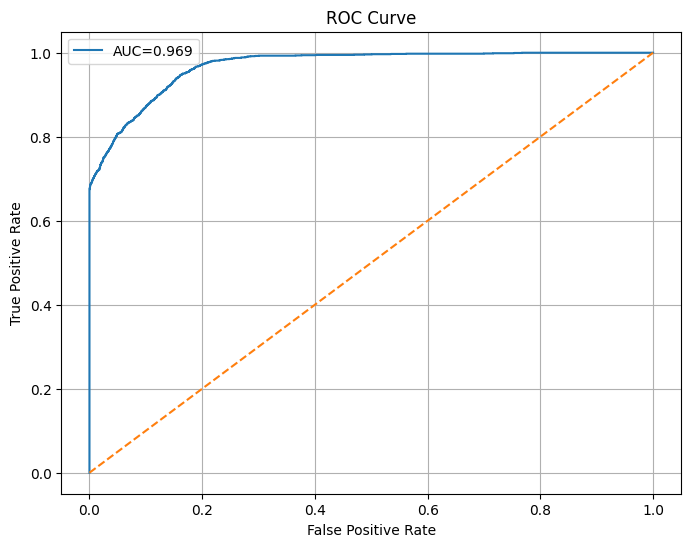

In [16]:
fpr,\
tpr,\
_=(
roc_curve(
y_test,
y_prob
))

roc_auc=(
auc(
fpr,
tpr
))

plt.figure(
figsize=(8,6)
)

plt.plot(
fpr,
tpr,

label=
f'AUC={roc_auc:.3f}'
)

plt.plot(
[0,1],
[0,1],
'--'
)

plt.xlabel(
'False Positive Rate'
)

plt.ylabel(
'True Positive Rate'
)

plt.title(
'ROC Curve'
)

plt.legend()

plt.grid()

plt.show()

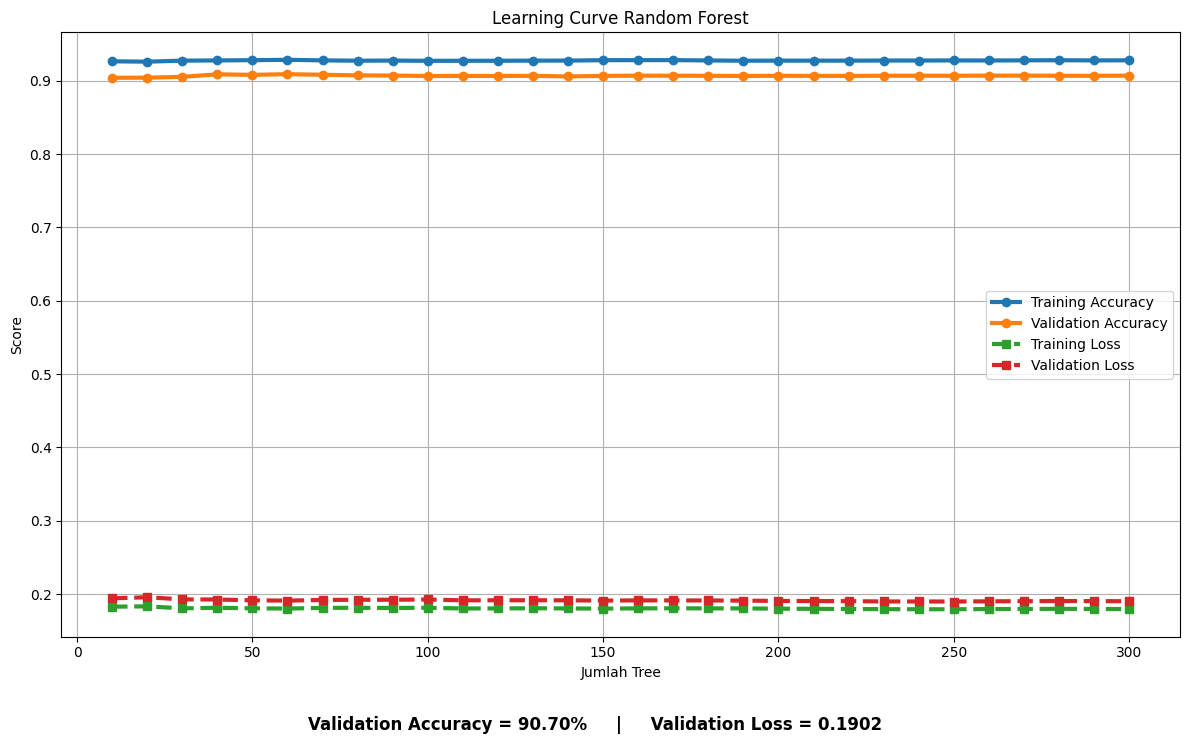

In [17]:
from sklearn.metrics import (
    accuracy_score,
    log_loss
)

train_acc=[]
val_acc=[]

train_loss=[]
val_loss=[]

trees=[]

for n in range(
    10,
    301,
    10
):

    model=RandomForestClassifier(
        n_estimators=n,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train
    )

    train_pred=(
        model.predict(
            X_train
        )
    )

    val_pred=(
        model.predict(
            X_test
        )
    )

    train_prob=(
        model.predict_proba(
            X_train
        )
    )

    val_prob=(
        model.predict_proba(
            X_test
        )
    )

    trees.append(n)

    train_acc.append(
        accuracy_score(
            y_train,
            train_pred
        )
    )

    val_acc.append(
        accuracy_score(
            y_test,
            val_pred
        )
    )

    train_loss.append(
        log_loss(
            y_train,
            train_prob
        )
    )

    val_loss.append(
        log_loss(
            y_test,
            val_prob
        )
    )

final_acc=val_acc[-1]
final_loss=val_loss[-1]

plt.figure(
    figsize=(12,7)
)

plt.plot(
    trees,
    train_acc,
    marker='o',
    linewidth=3,
    label='Training Accuracy'
)

plt.plot(
    trees,
    val_acc,
    marker='o',
    linewidth=3,
    label='Validation Accuracy'
)

plt.plot(
    trees,
    train_loss,
    marker='s',
    linestyle='--',
    linewidth=3,
    label='Training Loss'
)

plt.plot(
    trees,
    val_loss,
    marker='s',
    linestyle='--',
    linewidth=3,
    label='Validation Loss'
)

plt.title(
    'Learning Curve Random Forest'
)

plt.xlabel(
    'Jumlah Tree'
)

plt.ylabel(
    'Score'
)

plt.legend()

plt.grid()

plt.figtext(
    0.5,
    -0.05,

    f'Validation Accuracy = {final_acc*100:.2f}%     |     Validation Loss = {final_loss:.4f}',

    ha='center',

    fontsize=12,

    fontweight='bold'
)

plt.tight_layout()

plt.show()

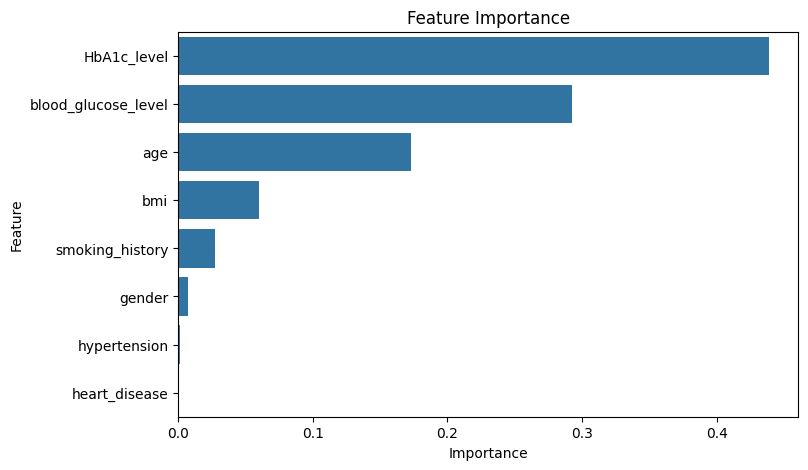

In [18]:
importance=(
rf.feature_importances_
)

feature=pd.DataFrame({

'Feature':
X.columns,

'Importance':
importance

})

feature=(
feature
.sort_values(
'Importance',

ascending=False
)
)

plt.figure(
figsize=(8,5)
)

sns.barplot(

data=feature,

x='Importance',

y='Feature'

)

plt.title(
'Feature Importance'
)

plt.show()

In [19]:
import joblib


joblib.dump(
    rf,
    "model_diabetes.pkl"
)


joblib.dump(
    le_gender,
    "encoder_gender.pkl"
)

joblib.dump(
    le_smoking,
    "encoder_smoking.pkl"
)

print(
"""
✅ File berhasil disimpan:

1. model_diabetes.pkl
2. encoder_gender.pkl
3. encoder_smoking.pkl
"""
)


✅ File berhasil disimpan:

1. model_diabetes.pkl
2. encoder_gender.pkl
3. encoder_smoking.pkl

